# 5. 모델 성능 평가

## 학습 목표

1. 이진분류, 다중분류, 회귀에 사용하는 평가 방법을 구별하여 사용할 수 있다.
2. 분류에서는 정확도만으로는 모델 성능을 충분히 설명할 수 없음을 불균형 데이터 사례로 설명할 수 있다.
3. Accuracy, Precision, Recall, F1 Score, Confusion Matrix, ROC-AUC, MAE, MSE, RMSE, R² 의 역할을 구분할 수 있다.

## 진행 순서

1. [기본 환경 확인 및 한글 폰트 셋팅](#part1)
2. [평가 지표](#part2)
3. [분류 모델 평가](#part3)
4. [회귀 모델 평가](#part4)
5. [종합 정리](#part5)

## 1. 기본 환경 확인 및 한글 폰트 셋팅

In [1]:
import torch                    # 딥러닝 프레임워크
import torch.nn as nn           # 신경망 레이어 모음 (Linear, ReLU 등)
from torch.utils.data import DataLoader, TensorDataset, random_split
# DataLoader: 데이터를 배치 단위로 나눠주는 도구
# TensorDataset: 텐서를 묶어 데이터셋으로 만드는 도구
# random_split: 데이터셋을 학습/검증용으로 나누는 도구
from torchvision import datasets, transforms  # 이미지 데이터셋과 변환 도구
import matplotlib.pyplot as plt  # 그래프 그리기 도구
import os, subprocess

torch.manual_seed(42)  # 난수 고정: 실행할 때마다 같은 결과가 나오도록 설정
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# GPU가 있으면 GPU 사용, 없으면 CPU 사용

# [설정] Colab 한글 폰트 — 실행만 하세요, 내용 이해는 불필요합니다
if 'COLAB_RELEASE_TAG' in os.environ:
    subprocess.run(['apt-get', '-qq', '-y', 'install', 'fonts-nanum'],capture_output=True)
    import matplotlib.font_manager as fm
    for f in fm.findSystemFonts(['/usr/share/fonts/truetype/nanum']):
        fm.fontManager.addfont(f)
    plt.rcParams['font.family'] = 'NanumGothic'
    plt.rcParams['axes.unicode_minus'] = False

print("PyTorch version:", torch.__version__)
print("Device:", device)

PyTorch version: 2.10.0+cpu
Device: cpu


In [2]:
# ===== 공통 유틸리티 =====

class Squeeze(nn.Module):
    """(N, 1) → (N,) 출력 차원을 줄이는 레이어"""
    def forward(self, x):
        return x.squeeze(-1)

def train_model(model, train_loader, val_loader, loss_fn, optimizer, epochs, print_every=2):
    """
    모델 학습 함수 — 다중 분류, 이진 분류, 회귀 모두에 사용합니다.
    학습/검증 손실을 기록하고 반환합니다.
    """
    history = {'train_loss': [], 'val_loss': []}
    for epoch in range(1, epochs + 1):
        # 학습
        model.train()
        t_loss, t_n = 0.0, 0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = loss_fn(model(xb), yb)
            loss.backward()
            optimizer.step()
            t_loss += loss.item() * len(xb)
            t_n += len(xb)

        # 검증
        model.eval()
        v_loss, v_n = 0.0, 0
        with torch.inference_mode():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                loss = loss_fn(model(xb), yb)
                v_loss += loss.item() * len(xb)
                v_n += len(xb)

        history['train_loss'].append(t_loss / t_n)
        history['val_loss'].append(v_loss / v_n)
        if epoch % print_every == 0:
            print(f"Epoch {epoch:2d} | train_loss={t_loss/t_n:.4f} val_loss={v_loss/v_n:.4f}")
    return history

def plot_loss_curve(history, title='Loss Curve'):
    """학습/검증 손실 곡선을 그립니다."""
    epochs = range(1, len(history['train_loss']) + 1)
    plt.figure(figsize=(7, 4))
    plt.plot(epochs, history['train_loss'], 'b-o', label='Train Loss')
    plt.plot(epochs, history['val_loss'], 'r-o', label='Val Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

#### train_model 함수에서 사용한 모드 전환 정리

위 `train_model()` 함수 안에서 `model.train()`, `model.eval()`, `torch.inference_mode()`를 사용합니다. 각각의 역할은 다음과 같습니다:

| 코드 | 역할 | 영향 |
|------|------|------|
| `model.train()` | **학습 모드**로 전환 | Dropout 활성화, BatchNorm이 현재 배치 통계 사용 |
| `model.eval()` | **평가 모드**로 전환 | Dropout 비활성화, BatchNorm이 누적 통계 사용 → 출력 안정 |
| `torch.inference_mode()` | **기울기 계산 비활성화** | 메모리 절약 + 속도 향상 (역전파 불필요한 구간) |

> **`eval()`과 `inference_mode()`는 서로 다른 일을 합니다.**
> - `eval()` → 레이어 동작 변경 (Dropout, BatchNorm)
> - `inference_mode()` → 기울기 추적 끄기 (메모리/속도)
>
> 검증·테스트 시에는 **둘 다** 사용해야 합니다.

**참고 — `inference_mode()` vs `no_grad()`:**

| 항목 | `torch.inference_mode()` | `torch.no_grad()` |
|------|--------------------------|---------------------|
| 속도 | 더 빠름 | 약간 느림 |
| 메모리 | 더 절약 | 절약 |
| 텐서 수정 | 불가 (읽기 전용) | 가능 |
| 권장 상황 | 순수 추론 (검증, 테스트) | 추론 + 텐서 수정 필요 시 |

## 2. 평가 지표

| 문제 유형 | 핵심 질문 | 주요 지표 |
|----------|----------|----------|
| **분류** | 정답 클래스를 맞혔는가? | Accuracy, Precision, Recall, F1, 혼동 행렬(Confusion Matrix), ROC-AUC |
| **회귀** | 예측값이 실제값에 얼마나 가까운가? | MAE, MSE, RMSE, R² |

### 왜 Accuracy만으로는 부족한가?

1,000명 중 암 환자 10명인 데이터에서 "모두 정상"이라고 예측하면:
- **Accuracy = 99.0%** → 숫자만 보면 훌륭해 보인다
- **암 환자 발견율(Recall) = 0%** → 실제로는 쓸모없는 모델이다

높은 Accuracy가 좋은 모델을 의미하지 않습니다. 이것이 **다양한 평가 지표가 필요한 이유**입니다.

> **생각해보기:** 99% 정확도의 암 진단 모델을 바로 병원에 도입해도 될까요? 어떤 추가 정보가 필요할까요?

In [3]:
# ===== 불균형 데이터에서 Accuracy 함정 시연 =====
# 1,000명 중 양성(암 환자) 10명인 상황을 시뮬레이션
dummy_targets = torch.cat([torch.ones(10), torch.zeros(990)])  # 실제: 양성 10명, 음성 990명
dummy_preds   = torch.zeros(1000)                               # 예측: 전부 "음성(정상)"

accuracy = (dummy_preds == dummy_targets).float().mean()
tp = ((dummy_preds == 1) & (dummy_targets == 1)).sum()          # 양성을 양성으로 맞힌 수
recall = tp.float() / dummy_targets.sum()                       # 실제 양성 중 찾아낸 비율

print(f"Accuracy: {accuracy:.1%}  → 높아 보이지만...")
print(f"Recall:   {recall:.1%}    → 암 환자를 하나도 못 찾았다!")

Accuracy: 99.0%  → 높아 보이지만...
Recall:   0.0%    → 암 환자를 하나도 못 찾았다!


## 3. 분류 모델 평가

> 이전 시간에 MNIST 데이터로 모델을 학습해봤습니다. 그런데 그 모델이 **정말 좋은 모델인지** 어떻게 판단할까요? 이번 시간에는 모델의 성능을 다양한 관점에서 평가하는 방법을 배웁니다.

**FashionMNIST** 데이터셋을 사용합니다.

- **B1. 다중 분류 (10클래스)**: Accuracy, Per-class Recall, Confusion Matrix
- **B2. 이진 분류 (2클래스)**: Precision, Recall, F1, 임계값(Threshold) 분석, ROC-AUC

### 분류 평가의 기본 용어

모델의 예측 결과는 4가지로 나눌 수 있습니다:

|  | 예측: 양성 | 예측: 음성 |
|---|---|---|
| **실제: 양성** | **TP** (True Positive) 맞힘 | **FN** (False Negative) 놓침 |
| **실제: 음성** | **FP** (False Positive) 오판 | **TN** (True Negative) 맞힘 |

**암 진단 사례로 이해하기:**
- **TP**: 실제 암 환자를 암이라고 맞힌 경우
- **FN**: 실제 암 환자를 정상이라고 놓친 경우 (위험!)
- **FP**: 정상인을 암이라고 오판한 경우 (불필요한 추가 검사)
- **TN**: 정상인을 정상이라고 맞힌 경우

Train: 50000, Val: 10000, Test: 10000


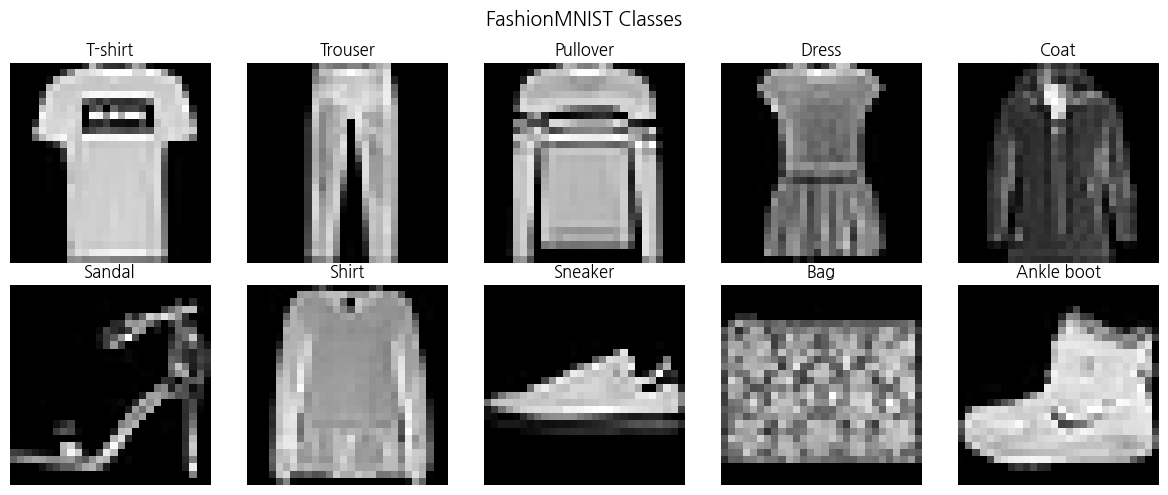

In [5]:
# ===== FashionMNIST 데이터 로드 =====
transform = transforms.ToTensor()  # [0, 255] -> [0.0, 1.0]

train_full = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
# 학습용 데이터 60,000장 다운로드
test_dataset = datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)
# 테스트용 데이터 10,000장 다운로드

# Train / Val 분할: 학습 50,000장 + 검증 10,000장
# 검증 데이터 = 학습 중간에 모델 성능을 확인하는 용도 (시험 전 모의고사 역할)
cls_train, cls_val = random_split(
    train_full, [50000, 10000],
    generator=torch.Generator().manual_seed(42)  # 분할 결과 고정
)

cls_train_loader = DataLoader(cls_train, batch_size=128, shuffle=True)   # 128장씩 묶어서 섞어 전달 (학습용)
cls_val_loader = DataLoader(cls_val, batch_size=256, shuffle=False)      # 256장씩 순서대로 전달 (검증용)
cls_test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)

# class_names = ['T-shirt', 'Trouser', 'Pullover', 'Dress', 'Coat',
#                'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
class_names = train_full.classes  # 데이터셋에서 클래스 이름을 직접 가져옴

print(f"Train: {len(cls_train)}, Val: {len(cls_val)}, Test: {len(test_dataset)}")

# 클래스별 샘플 이미지
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    indices = (train_full.targets == i).nonzero(as_tuple=False)  # 클래스 i의 인덱스 목록
    image, _ = train_full[indices[0].item()]                     # 첫 번째 샘플
    ax.imshow(image.squeeze(), cmap='gray')
    ax.set_title(class_names[i])
    ax.axis('off')
plt.suptitle('FashionMNIST Classes', fontsize=14)
plt.tight_layout()
plt.show()

### B1. 다중 분류 평가 (10클래스)

FashionMNIST 전체 10개 클래스를 분류하는 MLP를 학습하고 평가합니다.

> **logits(로짓)란?** 모델이 출력하는 원시 점수입니다. 아직 확률로 변환되기 전의 값으로, 값이 클수록 해당 클래스일 가능성이 높다는 의미입니다.

In [6]:
# ===== 다중 분류 모델 정의 =====
cls_model = nn.Sequential(
    nn.Flatten(),                         # (N, 1, 28, 28) -> (N, 784)
    nn.Linear(784, 256), nn.ReLU(),       # 은닉층 1
    nn.Linear(256, 128), nn.ReLU(),       # 은닉층 2
    nn.Linear(128, 10)                    # 출력층 (10클래스)
).to(device)

cls_loss_fn = nn.CrossEntropyLoss()       # 다중 분류용 손실 함수 (내부에 softmax 포함 → 모델 출력에 별도 softmax 불필요)
cls_optimizer = torch.optim.Adam(cls_model.parameters(), lr=0.001) # 모델의 가중치를 업데이트 대상으로 등록

# ===== 학습 (공통 함수 사용) =====
cls_history = train_model(cls_model, cls_train_loader, cls_val_loader,
                          cls_loss_fn, cls_optimizer, epochs=10, print_every=2)

Epoch  2 | train_loss=0.4015 val_loss=0.3758
Epoch  4 | train_loss=0.3271 val_loss=0.3403
Epoch  6 | train_loss=0.2900 val_loss=0.3049
Epoch  8 | train_loss=0.2655 val_loss=0.3191
Epoch 10 | train_loss=0.2423 val_loss=0.2893


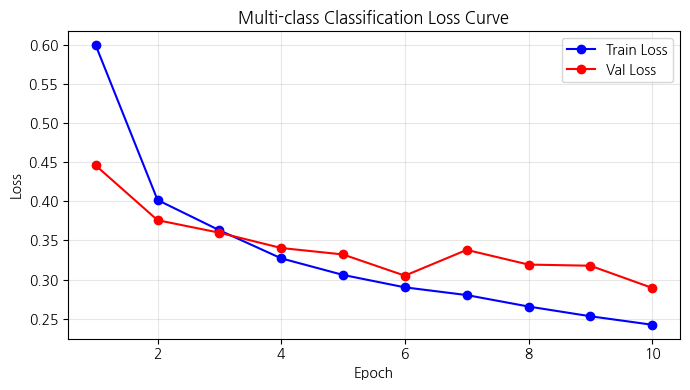

In [7]:
# ===== 학습 곡선 (공통 함수 사용) =====
# train_loss와 val_loss의 차이로 과적합 여부를 판단할 수 있음
plot_loss_curve(cls_history, title='Multi-class Classification Loss Curve')

#### 다중 분류 평가 지표

| 지표 | 수식 | 의미 |
|------|------|------|
| **Accuracy** | 맞힌 수 / 전체 수 | 전체 정답률 |
| **Per-class Recall** | TP_c / (TP_c + FN_c) | 클래스 c의 실제 데이터 중 맞힌 비율 |
| **Macro Recall** | 클래스별 Recall의 평균 | 모든 클래스를 동등하게 반영 |
| **Confusion Matrix** | (i, j) = 실제 i를 j로 예측한 횟수 | 모델의 혼동 패턴을 한눈에 파악 |

> **Accuracy가 높아도 특정 클래스의 Recall이 낮을 수 있습니다.** Confusion Matrix로 어떤 클래스끼리 혼동하는지 확인해야 합니다.

In [8]:
# ===== 다중 분류 테스트 평가 =====
cls_model.eval()
all_logits, all_targets = [], []

with torch.inference_mode():
    for xb, yb in cls_test_loader:
        xb = xb.to(device)
        logits = cls_model(xb)
        all_logits.append(logits.cpu())
        all_targets.append(yb)

all_logits = torch.cat(all_logits)
all_targets = torch.cat(all_targets)
all_preds = all_logits.argmax(dim=1)
# 각 샘플에 대해 10개 클래스 중 가장 높은 점수의 인덱스 = 예측 클래스 번호

# --- Accuracy ---
accuracy = (all_preds == all_targets).float().mean().item()
print(f"Test Accuracy: {accuracy:.4f}")

# --- Confusion Matrix (혼동 행렬) ---
# 10x10 표: cm[i][j] = 실제 클래스 i인데 클래스 j로 예측한 횟수
# 대각선(cm[i][i])이 클수록 좋음 = 정확히 맞힌 경우
num_classes = 10
cm = torch.zeros(num_classes, num_classes, dtype=torch.int64)
for t, p in zip(all_targets, all_preds):
    cm[t.long(), p.long()] += 1  # 실제t, 예측p 위치에 1 추가

# --- Per-class Precision / Recall / F1 ---
# Macro Recall: 클래스별 Recall을 구한 뒤 평균
correct_per_class = cm.diag().float()                  # 각 클래스의 정답 수 (대각선)
total_per_class   = cm.sum(dim=1).clamp(min=1).float() # 각 클래스의 전체 수 (행 합)
recall_per_class  = correct_per_class / total_per_class # 클래스별 Recall
macro_recall      = recall_per_class.mean().item()      # 전체 평균
print(f"\nMacro Recall: {macro_recall:.4f}")
print(f"\n{'Class':<12} {'Precision':>10} {'Recall':>10} {'F1':>10} {'Support':>10}")
print("-" * 57)

for c in range(num_classes):
    tp = cm[c, c].item()              # True Positive: 클래스 c를 c로 맞힌 수
    fn = (cm[c, :].sum() - tp).item() # False Negative: 실제 c인데 다른 클래스로 예측한 수
    fp = (cm[:, c].sum() - tp).item() # False Positive: 다른 클래스인데 c로 잘못 예측한 수
    support = cm[c, :].sum().item()   # 실제 클래스 c의 전체 샘플 수
    prec = tp / max(tp + fp, 1)       # Precision: 양성 예측 중 실제 양성 비율
    rec  = tp / max(tp + fn, 1)       # Recall: 실제 양성 중 찾아낸 비율
    f1   = 2 * prec * rec / max(prec + rec, 1e-8)  # F1: 조화평균
    print(f"{class_names[c]:<12} {prec:>10.4f} {rec:>10.4f} {f1:>10.4f} {support:>10.0f}")

Test Accuracy: 0.8878

Macro Recall: 0.8878

Class         Precision     Recall         F1    Support
---------------------------------------------------------
T-shirt          0.8455     0.8540     0.8498       1000
Trouser          0.9949     0.9690     0.9818       1000
Pullover         0.7759     0.8310     0.8025       1000
Dress            0.8813     0.9060     0.8935       1000
Coat             0.8215     0.7730     0.7965       1000
Sandal           0.9746     0.9600     0.9673       1000
Shirt            0.7117     0.7060     0.7088       1000
Sneaker          0.9340     0.9620     0.9478       1000
Bag              0.9856     0.9600     0.9726       1000
Ankle boot       0.9618     0.9570     0.9594       1000


**`(all_preds == all_targets).float().mean().item()` 코드 해설:**

| 단계 | 코드 | 예시 결과 | 설명 |
|------|------|----------|------|
| 1 | `all_preds == all_targets` | `[True, True, False, True, ...]` | 예측과 정답을 비교 |
| 2 | `.float()` | `[1.0, 1.0, 0.0, 1.0, ...]` | True→1.0, False→0.0 변환 |
| 3 | `.mean()` | `tensor(0.8878)` | 평균 = 맞힌 비율 |
| 4 | `.item()` | `0.8878` | 텐서에서 Python 숫자로 꺼냄 |

> `.item()`은 텐서를 일반 Python 숫자로 변환합니다. f-string 출력(`f"{accuracy:.4f}"`)에서 필요합니다.

**`cm[t.long(), p.long()] += 1` 코드 해설:**

실제 정답이 `Shirt(6)`이고 모델이 `T-shirt(0)`으로 예측한 경우:

| 단계 | 코드 | 결과 | 설명 |
|------|------|------|------|
| 1 | `t` | `tensor(6)` | 실제 클래스 (Shirt) |
| 2 | `p` | `tensor(0)` | 예측 클래스 (T-shirt) |
| 3 | `t.long(), p.long()` | `6, 0` | 정수형 변환 (인덱스로 사용하기 위해) |
| 4 | `cm[6, 0] += 1` | 해당 칸 +1 | "실제 Shirt인데 T-shirt로 잘못 예측" 횟수 누적 |

> 혼동 행렬에서 **대각선**(`cm[i, i]`)은 정답을 맞힌 경우, **비대각선**(`cm[i, j]`, i!=j)은 혼동한 경우입니다. 10,000개 샘플을 순회하며 해당 칸에 1씩 추가하면 혼동 행렬이 완성됩니다.

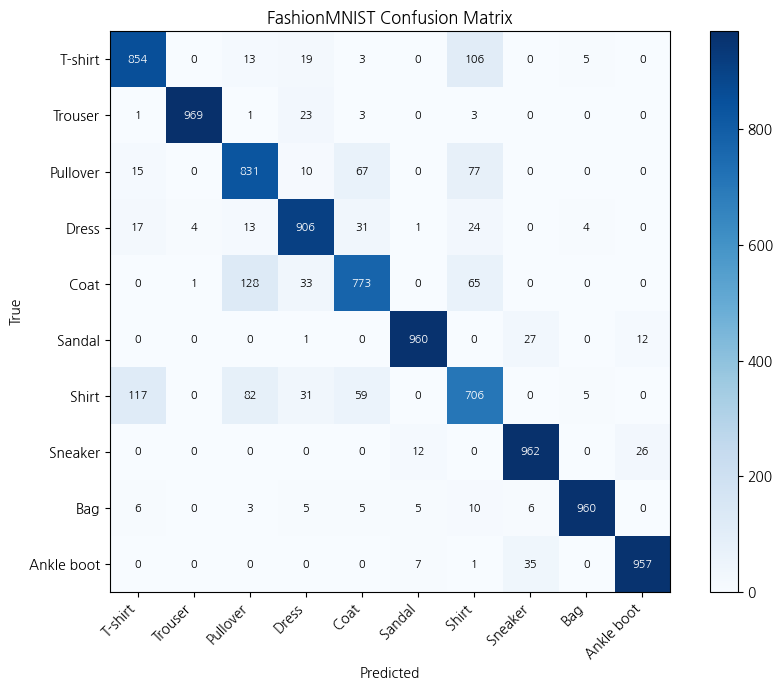

In [9]:
# ===== Confusion Matrix 시각화 =====
fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(cm.float(), cmap='Blues')  # 혼동 행렬을 히트맵으로 표시 (값이 클수록 진한 파랑)

ax.set_xticks(range(num_classes))
ax.set_yticks(range(num_classes))
ax.set_xticklabels(class_names, rotation=45, ha='right')
ax.set_yticklabels(class_names)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title('FashionMNIST Confusion Matrix')

# 각 칸에 숫자 표시
for i in range(num_classes):
    for j in range(num_classes):
        val = cm[i, j].item()
        # 배경이 진하면(값이 큰 칸) 흰색 글씨, 밝으면 검은 글씨
        color = 'white' if val > cm.max().item() * 0.5 else 'black'
        ax.text(j, i, str(val), ha='center', va='center', color=color, fontsize=8)

plt.colorbar(im)
plt.tight_layout()
plt.show()

#### 다중 분류 해석 가이드

**Confusion Matrix 읽는 법:**
- **대각선 (진한 칸)**: 정확하게 분류한 데이터
- **비대각선 (밝은 칸 중 값이 큰 곳)**: 모델이 자주 혼동하는 쌍

**FashionMNIST에서 자주 나타나는 혼동 패턴:**
- Shirt ↔ T-shirt ↔ Pullover ↔ Coat : 상의류끼리 시각적으로 유사
- Sneaker ↔ Ankle boot : 신발류끼리 유사

> 특정 클래스의 Recall이 낮다면, 해당 클래스 데이터를 더 수집하거나 모델 구조를 개선하는 방향을 검토합니다.

> **확인 질문:** 위 Confusion Matrix에서 Shirt가 가장 많이 혼동되는 클래스는 무엇인가요? 왜 그럴까요?

### B2. 이진 분류 평가

FashionMNIST에서 시각적으로 유사한 **Sneaker(7)**와 **Ankle boot(9)**만 추출하여 이진 분류기를 학습합니다.

#### Precision / Recall / F1 Score

| 지표 | 수식 | 의미 | 중요한 경우 |
|------|------|------|-----------|
| **Precision** | TP / (TP + FP) | 양성이라 한 것 중 실제 양성 비율 | FP 비용이 클 때 (스팸 필터) |
| **Recall** | TP / (TP + FN) | 실제 양성 중 찾아낸 비율 | FN 비용이 클 때 (암 진단) |
| **F1** | 2 × P × R / (P + R) | Precision과 Recall의 조화평균 | 둘 다 중요할 때 |

**직관적 비유:**
- **Precision** = 잡은 물고기 중 먹을 수 있는 비율 (쓰레기를 많이 건지면 낮아짐)
- **Recall** = 바다의 먹을 수 있는 물고기 중 실제로 잡은 비율 (많이 놓치면 낮아짐)
- **F1** = 종합 낚시 실력

In [10]:
# ===== 이진 분류 데이터 준비 =====
# FashionMNIST 전체 10클래스 중 Sneaker(7)와 Ankle boot(9)만 골라서
# "이것은 Sneaker인가 Ankle boot인가?"를 맞히는 이진(2개) 분류 문제를 만듦
# 참고: 다중 분류에서는 random_split으로 데이터를 나눴지만,
#       여기서는 특정 클래스만 필터링해야 하므로 텐서 인덱싱을 사용합니다

mask_train = (train_full.targets == 7) | (train_full.targets == 9)
# 클래스가 7(Sneaker) 또는 9(Ankle boot)인 데이터만 선택
bin_x_all = train_full.data[mask_train].float().unsqueeze(1) / 255.0
# .unsqueeze(1): (N, 28, 28) → (N, 1, 28, 28) 채널 차원 추가 / 255.0: 0~1 정규화
bin_y_all = (train_full.targets[mask_train] == 9).float()  # Sneaker=0(음성), Ankle boot=1(양성)

mask_test = (test_dataset.targets == 7) | (test_dataset.targets == 9)
bin_x_test = test_dataset.data[mask_test].float().unsqueeze(1) / 255.0
bin_y_test = (test_dataset.targets[mask_test] == 9).float()

# Train / Val 분할 (80 / 20)
n = len(bin_x_all)
idx = torch.randperm(n, generator=torch.Generator().manual_seed(42))
n_train = int(n * 0.8)

bin_train_loader = DataLoader(
    TensorDataset(bin_x_all[idx[:n_train]], bin_y_all[idx[:n_train]]),
    batch_size=128, shuffle=True)
bin_val_loader = DataLoader(
    TensorDataset(bin_x_all[idx[n_train:]], bin_y_all[idx[n_train:]]),
    batch_size=256, shuffle=False)
bin_test_loader = DataLoader(
    TensorDataset(bin_x_test, bin_y_test),
    batch_size=256, shuffle=False)

print(f"Sneaker(0): {(bin_y_all == 0).sum().item()}, Ankle boot(1): {(bin_y_all == 1).sum().item()}")
print(f"Train: {n_train}, Val: {n - n_train}, Test: {len(bin_x_test)}")

# ===== 이진 분류 모델 (다중 분류와 동일한 nn.Sequential 방식) =====
bin_model = nn.Sequential(
    nn.Flatten(),                    # (N, 1, 28, 28) → (N, 784)
    nn.Linear(784, 128), nn.ReLU(),  # 은닉층 1
    nn.Linear(128, 64), nn.ReLU(),   # 은닉층 2
    nn.Linear(64, 1),                # 출력: 1개 값 (양성일 확률의 원시 점수)
    Squeeze()                        # (N, 1) → (N,) 차원 줄이기
).to(device)

bin_loss_fn = nn.BCEWithLogitsLoss()      # 이진 분류용 손실 함수 (내부에 sigmoid 포함 → 모델 출력에 별도 sigmoid 불필요)
bin_optimizer = torch.optim.Adam(bin_model.parameters(), lr=0.001)

# ===== 학습 (공통 함수 사용) =====
bin_history = train_model(bin_model, bin_train_loader, bin_val_loader,
                          bin_loss_fn, bin_optimizer, epochs=10, print_every=2)

Sneaker(0): 6000, Ankle boot(1): 6000
Train: 9600, Val: 2400, Test: 2000
Epoch  2 | train_loss=0.1294 val_loss=0.1257
Epoch  4 | train_loss=0.1000 val_loss=0.1142
Epoch  6 | train_loss=0.0971 val_loss=0.1094
Epoch  8 | train_loss=0.0790 val_loss=0.1075
Epoch 10 | train_loss=0.0785 val_loss=0.1131


**`torch.randperm(n, generator=torch.Generator().manual_seed(42))` 코드 해설:**

| 단계 | 코드 | 결과 | 설명 |
|------|------|------|------|
| 1 | `torch.Generator().manual_seed(42)` | seed 고정된 난수 생성기 | 매번 같은 랜덤 결과를 보장 |
| 2 | `torch.randperm(n)` | `[2, 7, 4, 0, ...]` | 0~n-1을 무작위로 섞은 순열 |
| 3 | `idx[:n_train]` → train, `idx[n_train:]` → val | 분할 | 섞은 뒤 앞쪽은 학습, 뒤쪽은 검증 |

> 순서대로 자르면 데이터 편향이 생길 수 있으므로 **섞은 뒤 분할**합니다. seed를 42로 고정하면 모든 학생이 **같은 분할 결과**를 얻습니다.

> **관찰:** Epoch 8(val_loss=0.1075) → Epoch 10(val_loss=0.1131)으로 검증 손실이 올라갔습니다. train_loss는 계속 줄어드는데 val_loss가 올라가는 것은 종합 정리에서 다룰 **과적합 신호**일 수 있습니다.

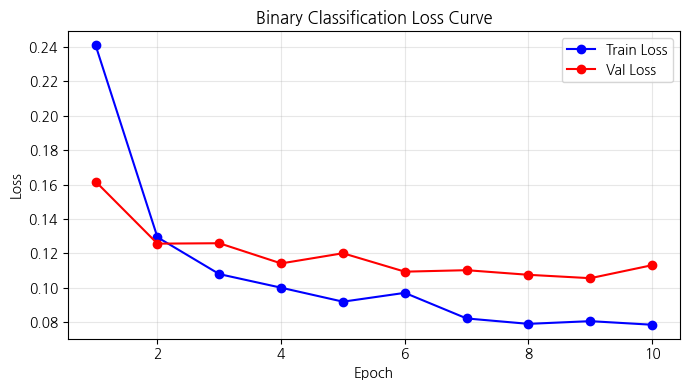

In [11]:
# ===== 이진 분류 학습 곡선 (공통 함수 사용) =====
plot_loss_curve(bin_history, title='Binary Classification Loss Curve')

In [12]:
# ===== 이진 분류 테스트 평가 =====
bin_model.eval()
bin_all_logits, bin_all_targets = [], []

with torch.inference_mode():
    for xb, yb in bin_test_loader:
        xb = xb.to(device)
        logits = bin_model(xb)
        bin_all_logits.append(logits.cpu())
        bin_all_targets.append(yb)

bin_all_logits = torch.cat(bin_all_logits)
bin_all_targets = torch.cat(bin_all_targets)
bin_all_probs = torch.sigmoid(bin_all_logits)
# sigmoid: 원시 점수(logits)를 0~1 사이의 확률값으로 변환
# 예: logits=2.0 → prob=0.88, logits=-1.0 → prob=0.27

# --- 이진 분류 지표 계산 함수 ---
def binary_metrics(probs, targets, threshold=0.5):
    """주어진 임계값(threshold)으로 양성/음성을 판정하고 각종 지표를 계산"""
    preds = (probs >= threshold).long()  # 확률 >= threshold이면 양성(1), 미만이면 음성(0)
    tp = ((preds == 1) & (targets == 1)).sum().item()  # True Positive: 양성을 양성으로 맞힘
    tn = ((preds == 0) & (targets == 0)).sum().item()  # True Negative: 음성을 음성으로 맞힘
    fp = ((preds == 1) & (targets == 0)).sum().item()  # False Positive: 음성을 양성으로 오판
    fn = ((preds == 0) & (targets == 1)).sum().item()  # False Negative: 양성을 음성으로 놓침

    accuracy  = (tp + tn) / max(tp + tn + fp + fn, 1)
    precision = tp / max(tp + fp, 1)
    recall    = tp / max(tp + fn, 1)
    f1 = 2 * precision * recall / max(precision + recall, 1e-8)
    return {'accuracy': accuracy, 'precision': precision,
            'recall': recall, 'f1': f1,
            'tp': tp, 'tn': tn, 'fp': fp, 'fn': fn}

# --- 기본 threshold 평가 ---
m = binary_metrics(bin_all_probs, bin_all_targets, threshold=0.5)
print(f"Accuracy:  {m['accuracy']:.4f}")
print(f"Precision: {m['precision']:.4f}")
print(f"Recall:    {m['recall']:.4f}")
print(f"F1 Score:  {m['f1']:.4f}")
print(f"\nTP={m['tp']}  FP={m['fp']}  FN={m['fn']}  TN={m['tn']}")

# --- Threshold별 비교 ---
print(f"\n{'Threshold':>10} {'Accuracy':>10} {'Precision':>10} {'Recall':>10} {'F1':>10}")
print("-" * 55)
for t in [0.3, 0.4, 0.5, 0.6, 0.7]:
    m = binary_metrics(bin_all_probs, bin_all_targets, threshold=t)
    print(f"{t:>10.1f} {m['accuracy']:>10.4f} {m['precision']:>10.4f} "
          f"{m['recall']:>10.4f} {m['f1']:>10.4f}")

Accuracy:  0.9645
Precision: 0.9567
Recall:    0.9730
F1 Score:  0.9648

TP=973  FP=44  FN=27  TN=956

 Threshold   Accuracy  Precision     Recall         F1
-------------------------------------------------------
       0.3     0.9580     0.9370     0.9820     0.9590
       0.4     0.9630     0.9495     0.9780     0.9635
       0.5     0.9645     0.9567     0.9730     0.9648
       0.6     0.9680     0.9652     0.9710     0.9681
       0.7     0.9675     0.9717     0.9630     0.9674


**`torch.cat(bin_all_logits)` 코드 해설:**

테스트 데이터 2,000개를 배치(256개씩)로 나눠 처리하므로, 결과가 여러 조각으로 나뉩니다. `torch.cat`은 이 조각들을 **하나의 텐서로 합칩니다.**

| 단계 | 상태 | 형태 |
|------|------|------|
| `append` 반복 중 | 리스트 안에 텐서 8개 | `[tensor(256,), tensor(256,), ..., tensor(232,)]` |
| `torch.cat()` 후 | 하나의 텐서 | `tensor(2000,)` |

> 이렇게 합쳐야 전체 데이터에 대한 Accuracy, Precision, Recall 등을 **한 번에** 계산할 수 있습니다.

#### Threshold(임계값) 해석

모델은 확률값을 출력하고, Threshold를 기준으로 양성/음성을 판정합니다. Threshold를 바꾸면 Precision과 Recall의 균형이 달라집니다.

| Threshold | 효과 | 적합한 상황 |
|-----------|------|-----------|
| **낮음** (0.3) | Recall ↑, Precision ↓ | FN 비용이 클 때 (암 진단: 환자를 놓치면 위험) |
| **기본** (0.5) | 균형 | 일반적인 경우 |
| **높음** (0.7) | Precision ↑, Recall ↓ | FP 비용이 클 때 (스팸 필터: 정상 메일을 차단하면 안 됨) |

> **핵심**: Threshold는 기술적 선택이 아니라 **비즈니스 의사결정**입니다. "놓치는 것(FN)과 오판하는 것(FP) 중 어느 쪽이 더 비싼가?"에 따라 조절합니다.

#### ROC-AUC

- **ROC 곡선**: Threshold를 0에서 1까지 바꾸면서 **TPR(= Recall)**과 **FPR**의 변화를 그린 그래프
  - FPR = FP / (FP + TN) : 실제 음성을 양성으로 잘못 예측한 비율
- **AUC (Area Under the Curve)**: ROC 곡선 아래 면적
  - **1.0** = 완벽한 분류
  - **0.5** = 랜덤 수준 (동전 던지기)
  - **0.9 이상** = 우수한 모델

> Threshold에 독립적인 단일 수치로 모델의 전체 판별력을 비교할 수 있습니다.

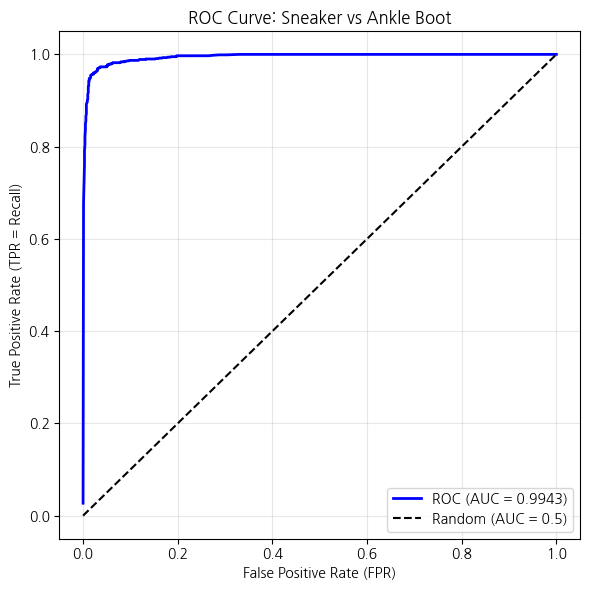

AUC: 0.9943


In [13]:
# ===== ROC-AUC 계산 (순수 PyTorch) =====

def compute_roc_auc(probs, targets, n_thresholds=500):
    """
    ROC 곡선과 AUC를 계산합니다.
    임계값을 1.0→0.0까지 500단계로 바꿔가며
    각 임계값에서의 TPR(=Recall)과 FPR을 계산합니다.
    """
    thresholds = torch.linspace(1.0, 0.0, n_thresholds)  # 500개 임계값 생성
    num_pos = (targets == 1).sum().float()  # 전체 양성(Ankle boot) 수
    num_neg = (targets == 0).sum().float()  # 전체 음성(Sneaker) 수
    tprs, fprs = [], []

    for t in thresholds:
        preds = (probs >= t).long()  # 현재 임계값으로 양성/음성 판정
        tp = ((preds == 1) & (targets == 1)).sum().float()
        fp = ((preds == 1) & (targets == 0)).sum().float()
        tprs.append((tp / num_pos).item() if num_pos > 0 else 0.0)  # TPR = Recall
        fprs.append((fp / num_neg).item() if num_neg > 0 else 0.0)  # FPR

    # AUC: ROC 곡선 아래 면적 (사다리꼴 공식으로 근사)
    # 1에 가까울수록 좋은 모델, 0.5면 랜덤 수준
    auc = 0.0
    for i in range(1, len(fprs)):
        auc += (fprs[i] - fprs[i-1]) * (tprs[i] + tprs[i-1]) / 2
    return fprs, tprs, auc

fprs, tprs, auc_score = compute_roc_auc(bin_all_probs, bin_all_targets)

plt.figure(figsize=(6, 6))
plt.plot(fprs, tprs, 'b-', linewidth=2, label=f'ROC (AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random (AUC = 0.5)')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR = Recall)')
plt.title('ROC Curve: Sneaker vs Ankle Boot')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"AUC: {auc_score:.4f}")
# 실무에서는 sklearn.metrics.roc_auc_score 또는 torchmetrics.AUROC를 사용합니다

### 분류 평가 정리

| 상황 | 확인할 지표 | 이유 |
|------|-----------|------|
| 클래스가 균형 잡힌 경우 | Accuracy + Confusion Matrix | Accuracy가 신뢰할 만함 |
| 클래스 불균형인 경우 | Recall, F1, Per-class metrics | Accuracy는 다수 클래스에 치우침 |
| 양성/음성 구분이 중요한 경우 | Precision + Recall + Threshold 분석 | 비즈니스 비용에 맞는 임계값 설정 |
| 모델 전체 판별력 비교 | ROC-AUC | Threshold에 독립적인 단일 수치 |

## 4. 회귀 모델 평가

**California Housing** 데이터셋으로 주택 가격(중간값)을 예측합니다.

> 데이터 로드에만 `sklearn.datasets`를 사용합니다 (Colab에 기본 설치됨). 평가 지표는 모두 PyTorch로 직접 계산합니다.

In [14]:
# ===== California Housing 데이터 로드 =====
from sklearn.datasets import fetch_california_housing
# sklearn은 데이터 다운로드에만 사용 (평가 지표는 PyTorch로 직접 계산)

data = fetch_california_housing()
X = torch.tensor(data.data, dtype=torch.float32)   # 입력 특성 (8개 변수)
y = torch.tensor(data.target, dtype=torch.float32)  # 정답: 주택 가격 (단위: $100,000)

# Train / Val / Test 분할 (60 / 20 / 20) — 정규화보다 먼저 분할해야 data leakage 방지
n = len(X)
idx = torch.randperm(n, generator=torch.Generator().manual_seed(42))
n_train = int(n * 0.6)
n_val   = int(n * 0.2)

# 특성 정규화: train set에서만 평균/표준편차를 계산 (val/test 정보 유출 방지)
# 특성마다 단위가 다르므로 (예: 인구수 vs 위도) 스케일을 통일해야 학습이 안정됨
X_mean = X[idx[:n_train]].mean(dim=0)  # train에서만 계산
X_std  = X[idx[:n_train]].std(dim=0)   # train에서만 계산
X = (X - X_mean) / (X_std + 1e-8)      # 전체에 동일 기준 적용

reg_train_loader = DataLoader(
    TensorDataset(X[idx[:n_train]], y[idx[:n_train]]),
    batch_size=128, shuffle=True)
reg_val_loader = DataLoader(
    TensorDataset(X[idx[n_train:n_train+n_val]], y[idx[n_train:n_train+n_val]]),
    batch_size=256, shuffle=False)
reg_test_loader = DataLoader(
    TensorDataset(X[idx[n_train+n_val:]], y[idx[n_train+n_val:]]),
    batch_size=256, shuffle=False)

print(f"Features: {X.shape[1]}  ({', '.join(data.feature_names)})")
print(f"Target: median house value ($100,000 units)")
print(f"Target range: {y.min().item():.2f} ~ {y.max().item():.2f}")
print(f"Train: {n_train}, Val: {n_val}, Test: {n - n_train - n_val}")

Features: 8  (MedInc, HouseAge, AveRooms, AveBedrms, Population, AveOccup, Latitude, Longitude)
Target: median house value ($100,000 units)
Target range: 0.15 ~ 5.00
Train: 12384, Val: 4128, Test: 4128


In [15]:
# ===== 회귀 모델 정의 (nn.Sequential 방식으로 통일) =====
reg_model = nn.Sequential(
    nn.Linear(8, 64), nn.ReLU(),   # 은닉층 1: 8→64
    nn.Linear(64, 32), nn.ReLU(),  # 은닉층 2: 64→32
    nn.Linear(32, 1),              # 출력: 1개 값 (주택 가격 예측)
    # 회귀 문제이므로 출력에 활성화 함수 없음 (값의 범위 제한이 없어야 함)
    Squeeze()                      # (N, 1) → (N,) 차원 줄이기
).to(device)

reg_loss_fn = nn.MSELoss()  # 회귀용 손실 함수: 예측값과 실제값의 차이를 제곱한 평균
reg_optimizer = torch.optim.Adam(reg_model.parameters(), lr=0.001)

# ===== 학습 (공통 함수 사용) =====
reg_history = train_model(reg_model, reg_train_loader, reg_val_loader,
                          reg_loss_fn, reg_optimizer, epochs=50, print_every=10)

Epoch 10 | train_loss=0.3745 val_loss=0.3772
Epoch 20 | train_loss=0.3248 val_loss=0.3315
Epoch 30 | train_loss=0.3033 val_loss=0.3133
Epoch 40 | train_loss=0.2918 val_loss=0.3053
Epoch 50 | train_loss=0.2806 val_loss=0.2984


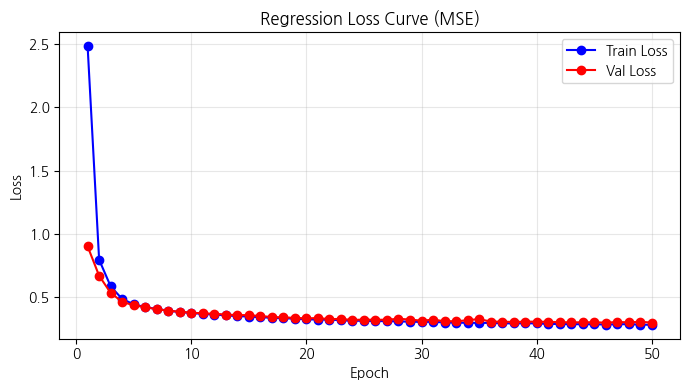

In [16]:
# ===== 회귀 학습 곡선 (공통 함수 사용) =====
plot_loss_curve(reg_history, title='Regression Loss Curve (MSE)')

#### 회귀 평가 지표

| 지표 | 수식 | 의미 |
|------|------|------|
| **MAE** | $$MAE = \frac{1}{n} \sum \lvert y - \hat{y} \rvert $$ | 평균 절대 오차 |
| **MSE** | $$MSE = \frac{1}{n} \sum (y - \hat{y})^2$$| 평균 제곱 오차 |
| **RMSE** | $$RMSE = \sqrt{\frac{1}{n} \sum (y - \hat{y})^2}$$ | MSE에 루트를 씌운 값 |
| **R²** | $$R^2 = 1 - \frac{\sum(y - \hat{y})^2}{\sum(y - \bar{y})^2}$$ | 1에서 (잔차 제곱합 / 전체 편차 제곱합)을 뺀 값. 1에 가까울수록 예측 정확도가 높음. |

- **R² = 1.0**: 완벽한 예측
- **R² = 0.0**: 평균값만 예측하는 것과 동일
- **R² < 0**: 평균값보다 못한 모델

In [17]:
# ===== 회귀 테스트 평가 =====
reg_model.eval()
reg_all_preds, reg_all_targets = [], []

with torch.inference_mode():
    for xb, yb in reg_test_loader:
        xb = xb.to(device)
        preds = reg_model(xb)
        reg_all_preds.append(preds.cpu())
        reg_all_targets.append(yb)

reg_all_preds = torch.cat(reg_all_preds)
reg_all_targets = torch.cat(reg_all_targets)

# --- 지표 계산 ---
mae  = torch.abs(reg_all_preds - reg_all_targets).mean().item()
# MAE: 예측 오차의 절대값 평균 ("평균적으로 이만큼 틀렸다")
mse  = ((reg_all_preds - reg_all_targets) ** 2).mean().item()
# MSE: 예측 오차를 제곱한 평균 (큰 오차에 더 큰 페널티)
rmse = mse ** 0.5
# RMSE: MSE에 루트를 씌운 값 (단위가 원래 데이터와 같아져서 해석이 쉬움)
ss_res = ((reg_all_targets - reg_all_preds) ** 2).sum()   # 잔차 제곱합
ss_tot = ((reg_all_targets - reg_all_targets.mean()) ** 2).sum()  # 전체 편차 제곱합
r2 = (1 - ss_res / ss_tot).item()
# R²: 모델이 데이터 변동의 몇 %를 설명하는지 (1.0=완벽, 0.0=평균만 예측)

print(f"MAE  : {mae:.4f}  (평균 ${mae * 100000:,.0f} 오차)")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}  (평균 ${rmse * 100000:,.0f} 오차)")
print(f"R²   : {r2:.4f}  (분산의 {r2*100:.1f}%를 설명)")

MAE  : 0.3642  (평균 $36,421 오차)
MSE  : 0.2819
RMSE : 0.5309  (평균 $53,094 오차)
R²   : 0.7944  (분산의 79.4%를 설명)


> **생각해보기:** MAE가 \$36,016이고 RMSE가 \$52,802입니다. 이 차이가 의미하는 것은 무엇일까요? (힌트: 아래 표를 확인해보세요)

#### MAE vs RMSE: 언제 무엇을 볼 것인가?

| 상황 | 선택 | 이유 |
|------|------|------|
| 이상치(outlier)가 많은 데이터 | **MAE** | 큰 오차에 과도한 페널티를 주지 않음 |
| 큰 오차가 치명적인 경우 | **RMSE** | 큰 오차를 더 강하게 반영 |
| 비즈니스 보고 | **MAE** | "평균적으로 X만큼 틀린다"고 직관적으로 설명 가능 |
| 모델 학습 중 loss | **MSE** | 미분이 연속적이어서 경사하강법 최적화에 유리 |

> **RMSE ≥ MAE**는 항상 성립합니다. 둘의 차이가 클수록 오차의 분산이 크다(큰 오차가 섞여 있다)는 신호입니다.

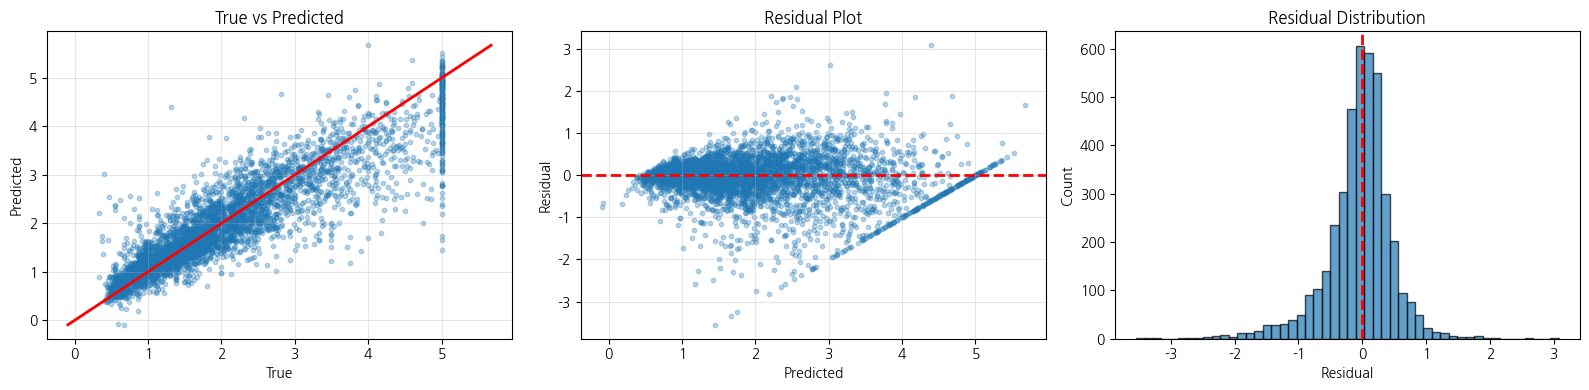

In [18]:
# ===== 잔차(Residual) 분석 =====
residuals = (reg_all_preds - reg_all_targets).detach().numpy()
# 잔차 = 예측값 - 실제값 (0에 가까울수록 좋은 예측)
targets_np = reg_all_targets.numpy()
preds_np = reg_all_preds.detach().numpy()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 1. True vs Predicted (실제값 vs 예측값 산점도)
# 점들이 빨간 대각선에 가까울수록 예측이 정확함
axes[0].scatter(targets_np, preds_np, alpha=0.3, s=10)
val_min = min(targets_np.min(), preds_np.min())
val_max = max(targets_np.max(), preds_np.max())
axes[0].plot([val_min, val_max], [val_min, val_max], 'r-', linewidth=2)  # 완벽한 예측선
axes[0].set_xlabel('True')
axes[0].set_ylabel('Predicted')
axes[0].set_title('True vs Predicted')
axes[0].grid(True, alpha=0.3)

# 2. Residual vs Predicted (잔차 산점도)
# 0선 주위에 무작위로 퍼져 있으면 정상, 패턴이 보이면 모델이 놓치는 관계가 있다는 신호
axes[1].scatter(preds_np, residuals, alpha=0.3, s=10)
axes[1].axhline(0, color='red', linestyle='--', linewidth=2)  # 잔차=0 기준선
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Residual')
axes[1].set_title('Residual Plot')
axes[1].grid(True, alpha=0.3)

# 3. Residual Distribution (잔차 분포)
# 0을 중심으로 좌우 대칭이면 이상적, 한쪽으로 치우치면 체계적 과대/과소 예측
axes[2].hist(residuals, bins=50, edgecolor='black', alpha=0.7)
axes[2].axvline(0, color='red', linestyle='--', linewidth=2)
axes[2].set_xlabel('Residual')
axes[2].set_ylabel('Count')
axes[2].set_title('Residual Distribution')

plt.tight_layout()
plt.show()

#### 잔차 분석 해석 가이드

| 그래프 | 이상적인 모습 | 문제 신호 |
|--------|-------------|----------|
| **True vs Predicted** | 점들이 대각선(빨간 선)에 밀집 | 특정 구간에서 대각선과 크게 벗어남 |
| **Residual Plot** | 0 주변에 무작위로 분포 | 패턴이 보임 (곡선, 부채꼴 형태) |
| **Residual Distribution** | 0 중심의 대칭 분포 | 한쪽으로 치우침, 긴 꼬리 |

**문제가 보이면:**
- 잔차에 **곡선 패턴** → 모델이 놓치는 비선형 관계 존재 → 모델 복잡도 증가
- 잔차가 **부채꼴 형태** → 예측값이 커질수록 오차 증가 → 타겟 로그 변환 검토
- 잔차가 **한쪽으로 치우침** → 체계적 과대/과소 예측 → 데이터 전처리 확인

## 5. 종합 정리

### 분류 vs 회귀 지표 비교

| | 분류 | 회귀 |
|---|------|------|
| **핵심 질문** | 클래스를 맞혔는가? | 값이 얼마나 가까운가? |
| **기본 지표** | Accuracy | MAE / RMSE |
| **세부 지표** | Precision, Recall, F1 | R² |
| **시각화** | Confusion Matrix, ROC Curve | True vs Pred, Residual Plot |
| **주의점** | 불균형 데이터에서 Accuracy 함정 | RMSE ≫ MAE이면 이상치 의심 |

### 학습 곡선 해석

| 패턴 | 의미 | 대응 |
|------|------|------|
| train_loss ↓, val_loss ↓ | 정상 학습 | 계속 학습 |
| train_loss ↓, val_loss → | 학습 수렴 | 학습 중단 |
| train_loss ↓, val_loss ↑ | **과적합** | 조기 종료, 정규화, 데이터 보강 |
| train_loss →, val_loss → | **과소적합** | 모델 복잡도 증가, 학습률 조정 |

### 정리 질문

1. Accuracy 95%인 모델이 있다. 바로 서비스에 배포해도 되는가? 어떤 추가 지표를 확인해야 하는가?
2. Precision과 Recall 중 하나만 높일 수 있다면, 암 진단에서는 어느 쪽을 택하겠는가?
3. MAE가 0.5이고 RMSE가 1.5인 모델이 있다. 이 차이가 알려주는 것은 무엇인가?
4. 학습 곡선에서 train_loss는 계속 줄어드는데 val_loss가 올라간다면 어떻게 대응하겠는가?